# Project #3 Code Using Only Lab-Style Coding
This notebook uses the same kind of coding patterns shown in the uploaded lab notebooks and uses the variables listed in your methods file.

In [135]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
sns.set_palette('deep')


In [136]:

# Load the datasets
nhts_data = pd.read_csv('NHTS.csv')
ngsim_data = pd.read_csv('NGSIM.csv')

# Look at the first few rows
print(nhts_data.head())
print(ngsim_data.head())


   household_id census_division census_region  driver_count  \
0    9000013002     New England     Northeast             2   
1    9000013002     New England     Northeast             2   
2    9000013016     New England     Northeast             2   
3    9000013039     New England     Northeast             2   
4    9000013041     New England     Northeast             1   

     household_income  household_size  household_workers  \
0    $175,000 or more               4                  1   
1    $175,000 or more               4                  1   
2  $75,000 to $99,999               2                  2   
3  $75,000 to $99,999               4                  1   
4    $175,000 or more               1                  1   

                            home_type household_location  \
0                 One-family detached              Urban   
1                 One-family detached              Urban   
2  Building with 2 or more apartments              Urban   
3  Building with 2 o

In [137]:

# column names
print("NHTS columns:")
print(nhts_data.columns)

print("NGSIM columns:")
print(ngsim_data.columns)


NHTS columns:
Index(['household_id', 'census_division', 'census_region', 'driver_count',
       'household_income', 'household_size', 'household_workers', 'home_type',
       'household_location', 'number_adults_household',
       'vehicles_per_household', 'travel_date', 'travel_day', 'urban',
       'vehicle_type', 'hybrid', 'make', 'vehicle_age', 'vehicle_commercial',
       'vehicle_delivery', 'vehicle_rideshare', 'fuel_type', 'vehicle_year'],
      dtype='object')
NGSIM columns:
Index(['Time', 'leader_position(m)', 'follower_position(m)',
       'leader_speed(m/s)', 'follower_speed(m/s)', 'leader_acc(m/s^2)',
       'follower_acc(m/s^2)', 'trajectory_number'],
      dtype='object')


In [153]:

# Keep only the variables named in the methods section
# NHTS variables: travel_day, vehicle_age, vehicle_type
nhts_subset = nhts_data[['travel_day', 'vehicle_age', 'vehicle_type']].dropna()

# NGSIM variables: Time, trajectory_number, leader/follower speed, acceleration, and position
ngsim_subset = ngsim_data[['trajectory_number',
                           'Time',
                           'leader_speed(m/s)',
                           'follower_speed(m/s)',
                           'leader_acc(m/s^2)',
                           'follower_acc(m/s^2)',
                           'leader_position(m)',
                           'follower_position(m)']].dropna()

print(nhts_subset.head())
print(ngsim_subset.head())


  travel_day  vehicle_age                       vehicle_type
0     Sunday            7  SUV (Santa Fe, Tahoe, Jeep, etc.)
1     Sunday            3  SUV (Santa Fe, Tahoe, Jeep, etc.)
2  Wednesday           11        Automobile/car/stationwagon
3   Thursday            7        Automobile/car/stationwagon
4     Monday            8        Automobile/car/stationwagon
   trajectory_number  Time  leader_speed(m/s)  follower_speed(m/s)  \
0                  1   0.1             14.054               14.484   
1                  1   0.2             14.164               14.481   
2                  1   0.3             14.063               14.478   
3                  1   0.4             13.835               14.484   
4                  1   0.5             13.746               14.481   

   leader_acc(m/s^2)  follower_acc(m/s^2)  leader_position(m)  \
0            1.09730        -3.048000e-02              26.654   
1           -1.00580        -3.048000e-02              28.060   
2           -2.286

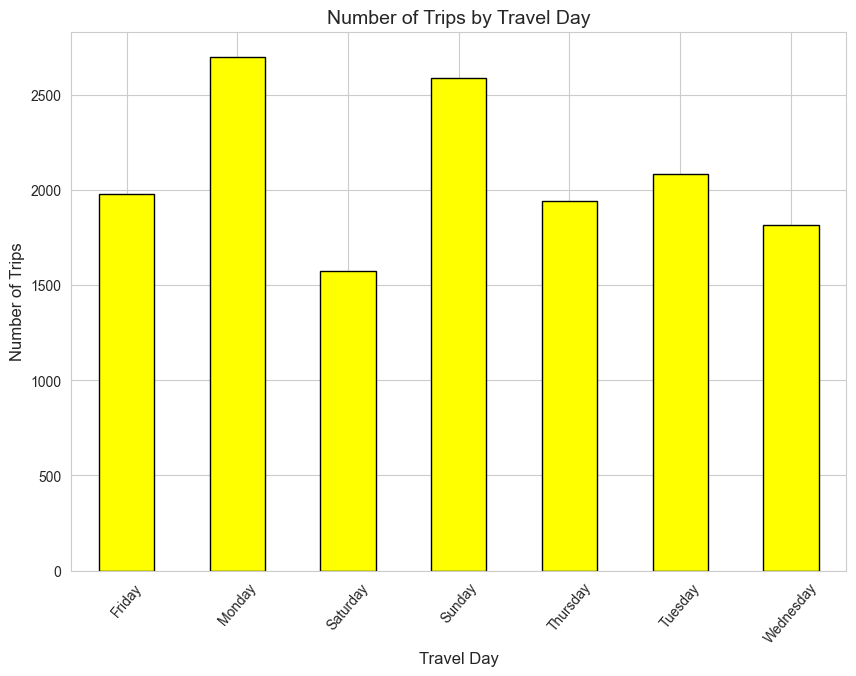

In [154]:

# Bar Chart Count trips by travel day

travel_day_counts = nhts_subset['travel_day'].value_counts().sort_index()

plt.figure(figsize=(10,7))
travel_day_counts.plot(kind='bar', color='yellow', edgecolor='black')
plt.xlabel('Travel Day', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.title('Number of Trips by Travel Day', fontsize=14)
plt.xticks(rotation=50)
plt.show()


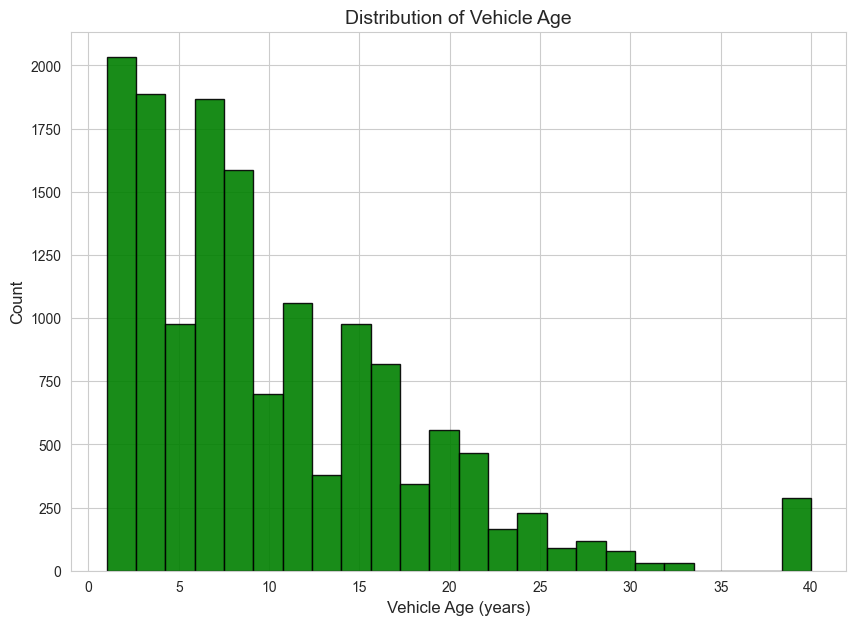

In [155]:

#histogram Vehicle age distribution

plt.figure(figsize=(10,7))
plt.hist(nhts_subset['vehicle_age'], bins=24, color='green', edgecolor='black', alpha=0.9)
plt.xlabel('Vehicle Age (years)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Vehicle Age', fontsize=14)
plt.show()


<Figure size 1200x700 with 0 Axes>

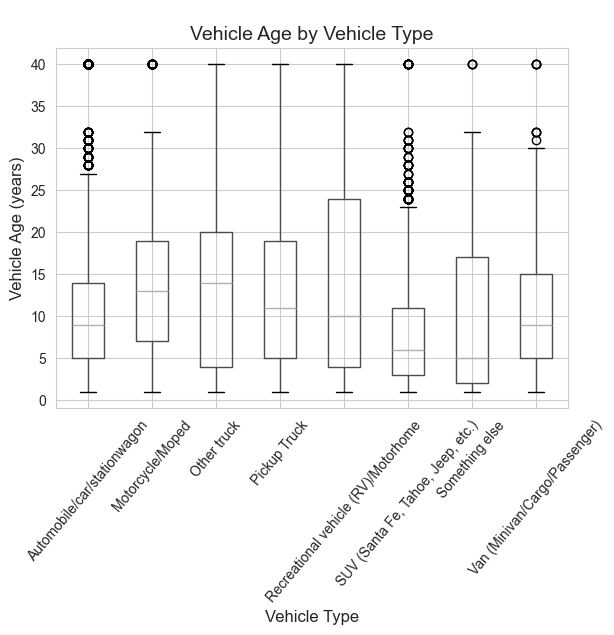

In [156]:

# Boxplot Vehicle age by vehicle type

plt.figure(figsize=(12,7))
nhts_subset.boxplot(column='vehicle_age', by='vehicle_type')
plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('Vehicle Age (years)', fontsize=12)
plt.title('Vehicle Age by Vehicle Type', fontsize=14)
plt.suptitle(' ')
plt.xticks(rotation=50)
plt.show()


In [157]:

# one trajectory for the time-series plots
trajectory_number = 3
data_subset = ngsim_subset[ngsim_subset['trajectory_number'] == trajectory_number].reset_index(drop=True)

print(data_subset.head())


   trajectory_number  Time  leader_speed(m/s)  follower_speed(m/s)  \
0                  3   0.1             13.045               13.716   
1                  3   0.2             13.375               13.716   
2                  3   0.3             13.591               13.716   
3                  3   0.4             13.734               13.716   
4                  3   0.5             13.759               13.716   

   leader_acc(m/s^2)  follower_acc(m/s^2)  leader_position(m)  \
0            3.29180         0.000000e+00              19.089   
1            2.16410        -7.110000e-14              20.394   
2            1.43260         1.420000e-13              21.731   
3            0.24384        -8.880000e-14              23.090   
4           -0.33528        -8.880000e-14              24.464   

   follower_position(m)  
0                0.0000  
1                1.3716  
2                2.7432  
3                4.1148  
4                5.4864  


In [158]:

# Create spacing variable
data_subset['spacing'] = data_subset['leader_position(m)'] - data_subset['follower_position(m)']

print(data_subset[['Time', 'leader_position(m)', 'follower_position(m)', 'spacing']].head())


   Time  leader_position(m)  follower_position(m)  spacing
0   0.1              19.089                0.0000  19.0890
1   0.2              20.394                1.3716  19.0224
2   0.3              21.731                2.7432  18.9878
3   0.4              23.090                4.1148  18.9752
4   0.5              24.464                5.4864  18.9776


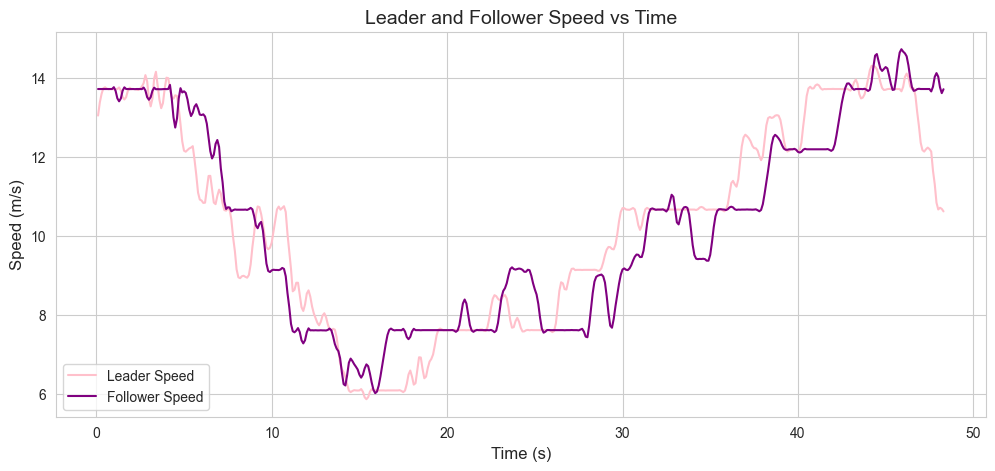

In [159]:

# 1st Time series plot 1 Leader speed and follower speed vs time

plt.figure(figsize=(12,5))
sns.lineplot(data=data_subset, x='Time', y='leader_speed(m/s)', label='Leader Speed', color='pink')
sns.lineplot(data=data_subset, x='Time', y='follower_speed(m/s)', label='Follower Speed', color='purple')
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Speed (m/s)', fontsize=12)
plt.title('Leader and Follower Speed vs Time', fontsize=14)
plt.legend()
plt.show()

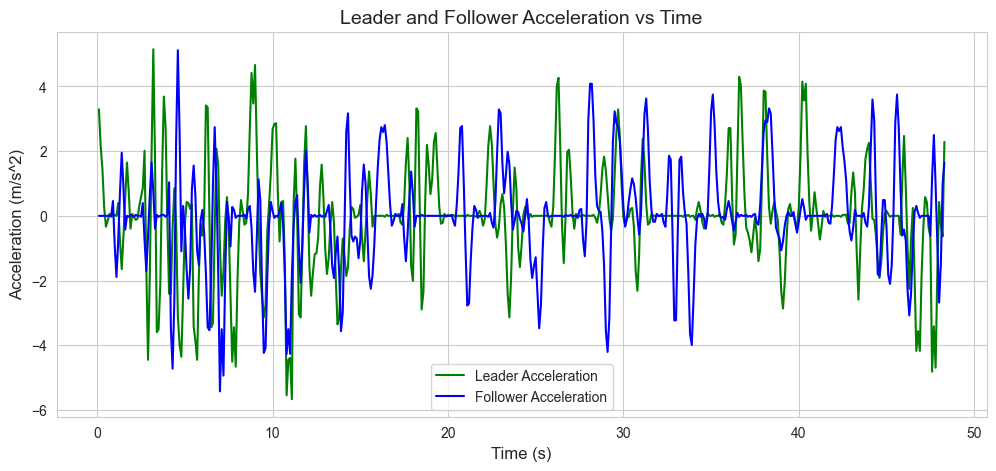

In [160]:

# 2nd Time series plot Leader acceleration and follower acceleration vs time

plt.figure(figsize=(12,5))
sns.lineplot(data=data_subset, x='Time', y='leader_acc(m/s^2)', label='Leader Acceleration', color='green')
sns.lineplot(data=data_subset, x='Time', y='follower_acc(m/s^2)', label='Follower Acceleration', color='blue')
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Acceleration (m/s^2)', fontsize=12)
plt.title('Leader and Follower Acceleration vs Time', fontsize=14)
plt.legend()
plt.show()

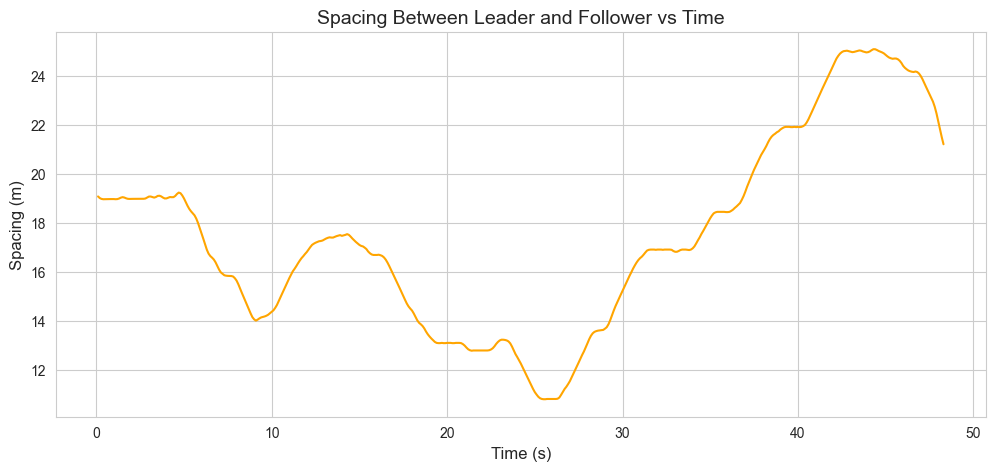

In [161]:

# EXTRA 3rd Time series plot Spacing vs time

plt.figure(figsize=(12,5))
plt.plot(data_subset['Time'], data_subset['spacing'], color='orange', linewidth=1.5)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Spacing (m)', fontsize=12)
plt.title('Spacing Between Leader and Follower vs Time', fontsize=14)
plt.show()


In [162]:

# Defining IDM acceleration function

def idm_acceleration(cs, gap, delta_v, d_speed, mini_g, t, max_a, b, delta):
    d_gap = mini_g + cs * t + (cs * delta_v) / (2 * np.sqrt(max_a * b))
    d_gap = max(d_gap, mini_g)
    output = max_a * (1 - (cs / d_speed) ** delta - (d_gap / gap) ** 2)
    return output


In [163]:

def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    s_star = max(s_star, s0)
    acceleration = a * (1 - (v / v0) ** delta - (s_star / s) ** 2)
    return acceleration




# Data for IDM simulation

time_data = data_subset['Time'].values
leader_position = data_subset['leader_position(m)'].values
leader_speed = data_subset['leader_speed(m/s)'].values
actual_follower_position = data_subset['follower_position(m)'].values
actual_follower_speed = data_subset['follower_speed(m/s)'].values
actual_follower_acc = data_subset['follower_acc(m/s^2)'].values

dt = 0.1

# IDM parameters

d_speed = 30
mini_g = 2
t = 1.5
max_a = 1.0
b = 1.5
delta = 4

# Initialize arrays

n_steps = len(time_data)
sim_position = np.zeros(n_steps)
sim_speed = np.zeros(n_steps)
sim_acc = np.zeros(n_steps)

# Start the simulation using the actual follower starting values

sim_position[0] = actual_follower_position[0]
sim_speed[0] = actual_follower_speed[0]


In [164]:

# Run the IDM simulation
for i in range(n_steps - 1):
    gap = max(leader_position[i] - sim_position[i], 0.1)
    delta_v = sim_speed[i] - leader_speed[i]
    
    sim_acc[i] = idm_acceleration(sim_speed[i], gap, delta_v, d_speed, mini_g, t, max_a, b, delta)
    
    sim_speed[i + 1] = max(sim_speed[i] + sim_acc[i] * dt, 0)
    sim_position[i + 1] = sim_position[i] + sim_speed[i] * dt
    
print("Simulation complete!")


Simulation complete!


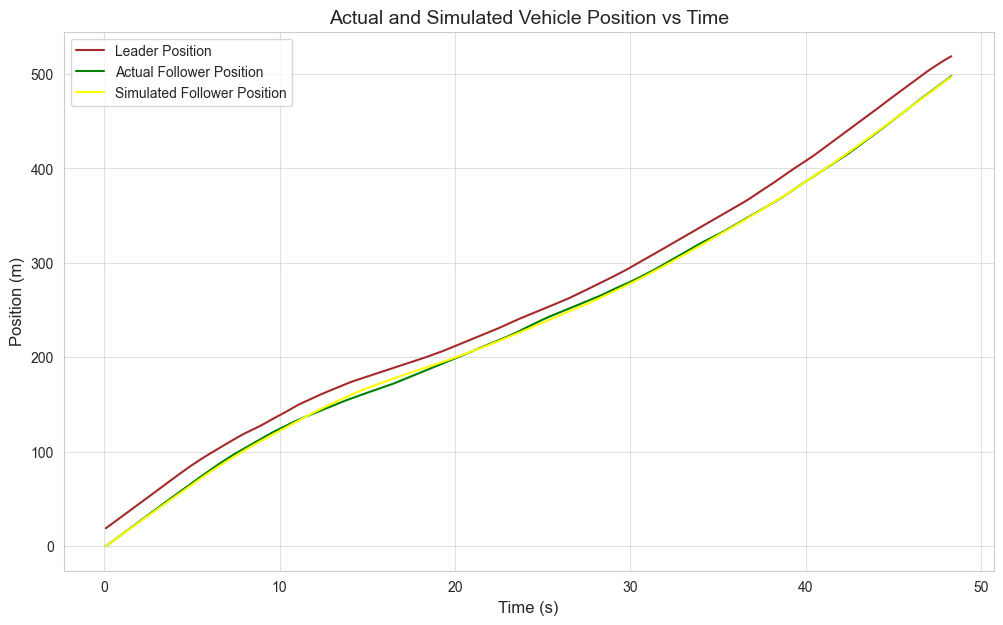

In [165]:

# Compare actual and simulated follower position

plt.figure(figsize=(12,7))
plt.plot(time_data, leader_position, label='Leader Position', color='brown')
plt.plot(time_data, actual_follower_position, label='Actual Follower Position', color='green')
plt.plot(time_data, sim_position, label='Simulated Follower Position', color='yellow')
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Position (m)', fontsize=12)
plt.title('Actual and Simulated Vehicle Position vs Time', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.6)
plt.show()


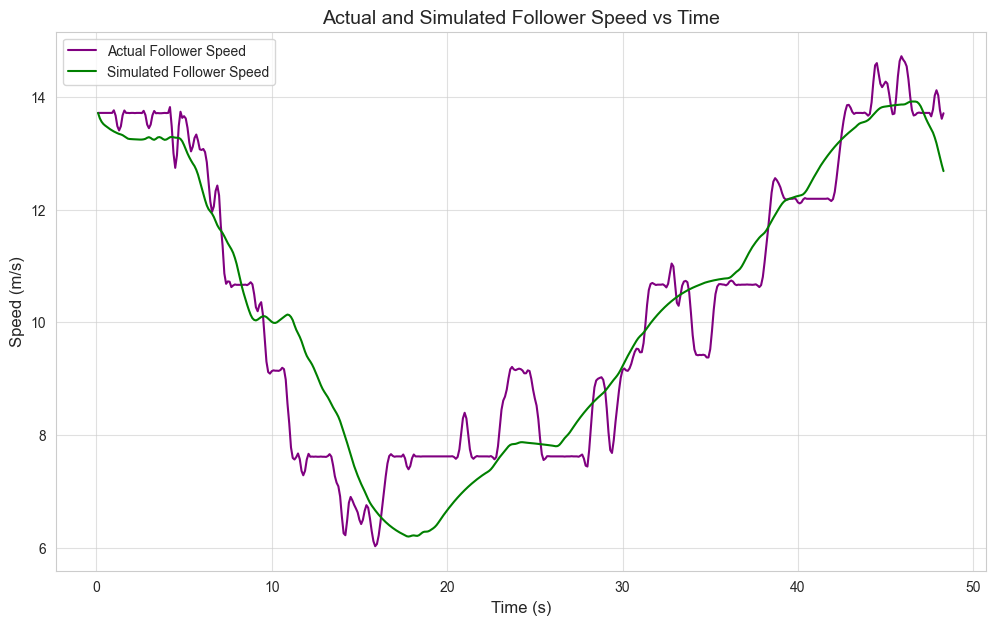

In [166]:

# Compare actual and simulated follower speed

plt.figure(figsize=(12,7))
plt.plot(time_data, actual_follower_speed, label='Actual Follower Speed', color='purple')
plt.plot(time_data, sim_speed, label='Simulated Follower Speed', color='green')
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Speed (m/s)', fontsize=12)
plt.title('Actual and Simulated Follower Speed vs Time', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.6)
plt.show()


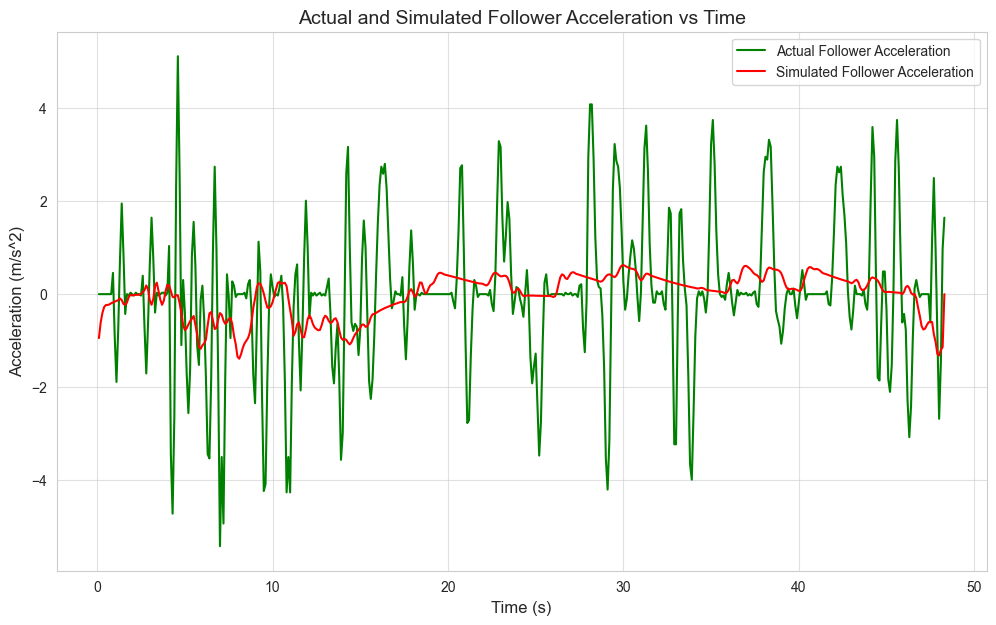

In [167]:

# Compare actual and simulated follower acceleration

plt.figure(figsize=(12,7))
plt.plot(time_data, actual_follower_acc, label='Actual Follower Acceleration', color='green')
plt.plot(time_data, sim_acc, label='Simulated Follower Acceleration', color='red')
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Acceleration (m/s^2)', fontsize=12)
plt.title('Actual and Simulated Follower Acceleration vs Time', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.6)
plt.show()


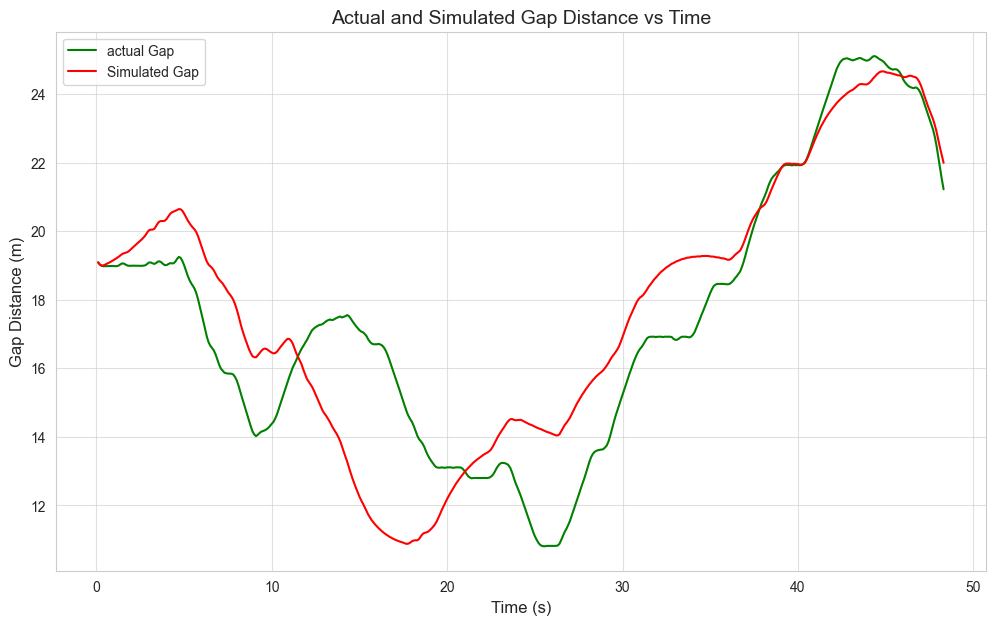

In [168]:

# Compare actual and simulated gap distance

actual_gap = leader_position - actual_follower_position
sim_gap = leader_position - sim_position

plt.figure(figsize=(12,7))
plt.plot(time_data, actual_gap, label='actual Gap', color='green')
plt.plot(time_data, sim_gap, label='Simulated Gap', color='red')
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Gap Distance (m)', fontsize=12)
plt.title('Actual and Simulated Gap Distance vs Time', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.6)
plt.show()
